# ICVar figures: main-text Figures 1–8

Reproduces the main-text figures of

> Mukherjee, N., Gao, B., Coon, E. T., Shuai, P., Hill, D., Neilson, B. T., Cory, R. M., Kling, G. W., Chen, J., & Cardenas, M. B.
> *The Effects of Precipitation Variability on Supra-Permafrost Thermal Hydrology: Flashy Hillslopes with More Outflow.*
> Submitted to Water Resources Research.


In [1]:
import os
import sys
from collections import defaultdict
from datetime import datetime, timedelta

import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from scipy.stats import false_discovery_control, kendalltau, theilslopes

# ats_xdmf (ATS visualization reader): $ATS_SRC_DIR/tools/utils, or the authors' install
for _p in [os.path.join(os.environ.get("ATS_SRC_DIR", ""), "tools", "utils"),
           "/home/nm32873/ATS/ats-1.6-dev-414f81aa/repos/amanzi/src/physics/ats/tools/utils"]:
    if os.path.isfile(os.path.join(_p, "ats_xdmf.py")) and _p not in sys.path:
        sys.path.append(_p)
import ats_xdmf

mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300

## Settings

In [2]:
RUNS = "../runs"
DATA = "../data"
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

SIGMAS = list(range(9))                      # run index 0..8  ->  manuscript sigma_1..sigma_9
SHARED_SEED_REPS = list("abcdefgh")          # same random seeds across all sigma levels
UNIQUE_SEED_REPS = list("ijkl")              # independent random seeds per sigma level
REPS = SHARED_SEED_REPS + UNIQUE_SEED_REPS
YEAR_LEN = 365
SEASON = (150, 260)                          # day-of-year window plotted for the thaw season

# Molar density of liquid water used to convert ATS fluxes [mol] -> [m^3]
MOL_PER_M3 = 55500.0

SIGMA_COLORS = {s: plt.get_cmap("turbo", len(SIGMAS))(s) for s in SIGMAS}


def ms(s):
    """Manuscript label for run index s (0-based -> sigma_1..sigma_9)."""
    return rf"$\sigma_{{{s + 1}}}$"


def savefig(fig, name):
    fig.savefig(os.path.join(FIGDIR, name), bbox_inches="tight")

## Load ensemble observations

Each run writes one row per day to `observation_2D.dat` (see `dd.csv` for column definitions). Every σ level is split into twelve 365-day thaw-season realizations:

* **a–e**: BASE years 2–6 (year 1 is discarded as warm-up)
* **f–h**: EXTRA years 1–3
* **i–l**: SEEDS years 1–4

Within each realization the row index runs 1…365 (day of year).

In [3]:
def read_obs(run_dir):
    return pd.read_csv(os.path.join(RUNS, run_dir, "observation_2D.dat"), comment="#")


def split_years(df, n_years):
    block = df.tail(n_years * YEAR_LEN).reset_index(drop=True)
    assert len(block) == n_years * YEAR_LEN
    out = []
    for k in range(n_years):
        seg = block.iloc[k * YEAR_LEN:(k + 1) * YEAR_LEN].copy()
        seg.index = range(1, YEAR_LEN + 1)
        out.append(seg)
    return out


ens = defaultdict(dict)          # ens[sigma][rep] -> DataFrame (365 rows)
for s in SIGMAS:
    base = read_obs(f"run03_transect_base_sigma{s}_6yr").tail(5 * YEAR_LEN)
    extra = read_obs(f"run04_transect_extra_sigma{s}_3yr").tail(3 * YEAR_LEN)
    seeds = read_obs(f"run05_transect_seeds_sigma{s}_4yr").tail(4 * YEAR_LEN)
    years = split_years(pd.concat([base, extra], ignore_index=True), 8) + split_years(seeds, 4)
    for rep, seg in zip(REPS, years):
        ens[s][rep] = seg

print(f"{len(ens)} sigma levels x {len(ens[0])} realizations, {len(ens[0]['a'])} days each")

9 sigma levels x 12 realizations, 365 days each


## Figure 1: forcing and model mesh

Top panel: the 40-year (1981–2020) day-of-year mean meteorological forcing from the NASA DAAC ABoVE SnowModel dataset (Liston et al., 2023), applied identically in every simulation. Rain is replaced by the synthetic ensembles of Figure 2. Right panel: the subsurface mesh near the surface, coloured by soil layer.

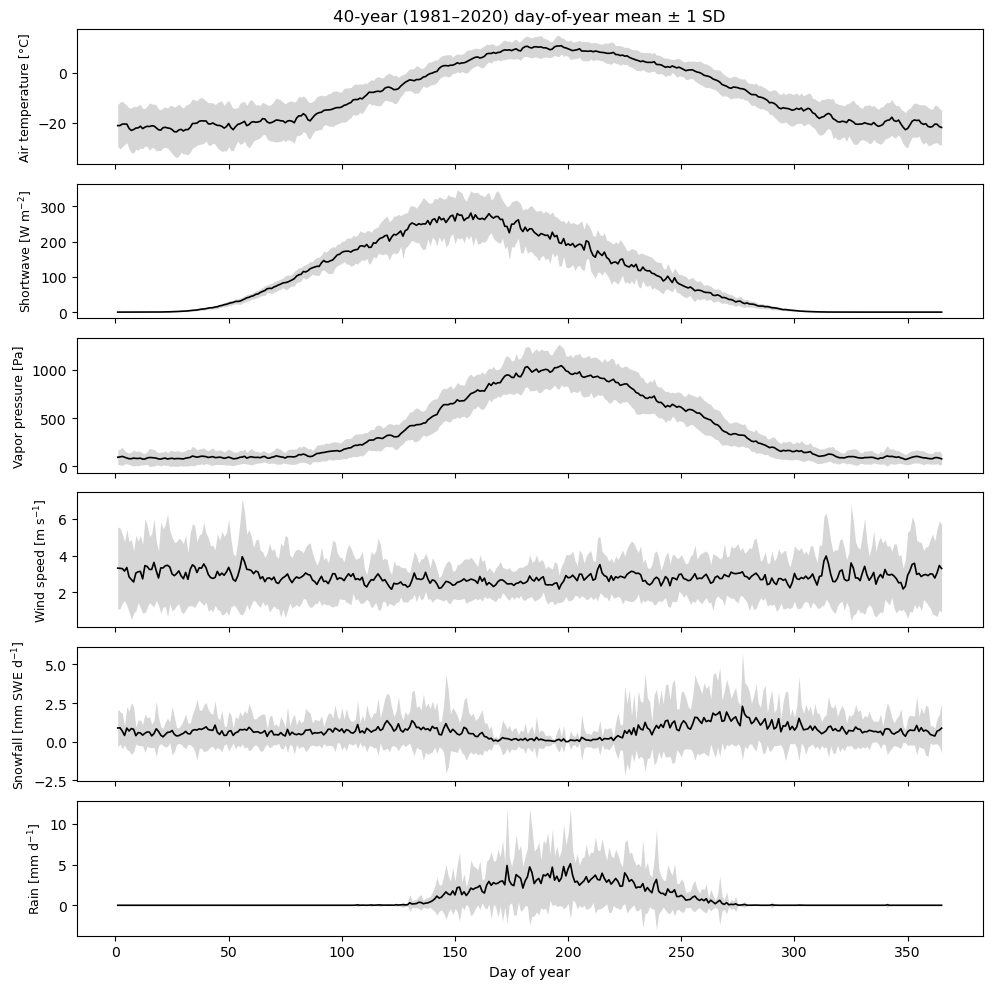

max |model T_air - DOY mean| [K]: 0.0


In [4]:
with h5py.File(os.path.join(DATA, "forcing_daac_ABoVE_snowmodel_1981_2020.h5"), "r") as f:
    daac = pd.DataFrame({k: f[k][:] for k in f.keys() if f[k].ndim == 1})
daac["Date"] = pd.date_range("1981-01-01", "2020-08-31", freq="D")
daac["DOY"] = daac["Date"].dt.dayofyear

FORCING_VARS = [
    ("air temperature [K]", "Air temperature [°C]", lambda v: v - 273.15),
    ("incoming shortwave radiation [W m^-2]", "Shortwave [W m$^{-2}$]", lambda v: v),
    ("vapor pressure air [Pa]", "Vapor pressure [Pa]", lambda v: v),
    ("wind speed [m s^-1]", "Wind speed [m s$^{-1}$]", lambda v: v),
    ("Precipitation Snow [m SWE s^-1]", "Snowfall [mm SWE d$^{-1}$]", lambda v: v * 8.64e7),
    ("Precipitation Rain [m s^-1]", "Rain [mm d$^{-1}$]", lambda v: v * 8.64e7),
]
g = daac[daac["DOY"] <= 365].groupby("DOY")

fig, axes = plt.subplots(len(FORCING_VARS), 1, figsize=(10, 10), sharex=True)
for ax, (col, label, conv) in zip(axes, FORCING_VARS):
    mu, sd = conv(g[col].mean()), g[col].std() * (conv(1.0) - conv(0.0))
    ax.plot(mu.index, mu, color="k", lw=1.2)
    ax.fill_between(mu.index, mu - sd, mu + sd, color="0.6", alpha=0.4, lw=0)
    ax.set_ylabel(label, fontsize=9)
axes[-1].set_xlabel("Day of year")
axes[0].set_title("40-year (1981–2020) day-of-year mean ± 1 SD")
fig.tight_layout()
savefig(fig, "Fig1_forcing_doy_mean.pdf")
plt.show()

# Check: non-rain forcing used by the model is the day-of-year mean shown above
with h5py.File(os.path.join(DATA, "synthetic_rainfall_ensemble_6yr.h5"), "r") as f:
    model_tair = f["air temperature [K]"][:YEAR_LEN]
doy_mean_tair = g["air temperature [K]"].mean().values[:YEAR_LEN]
print("max |model T_air - DOY mean| [K]:", np.abs(model_tair - doy_mean_tair).max())

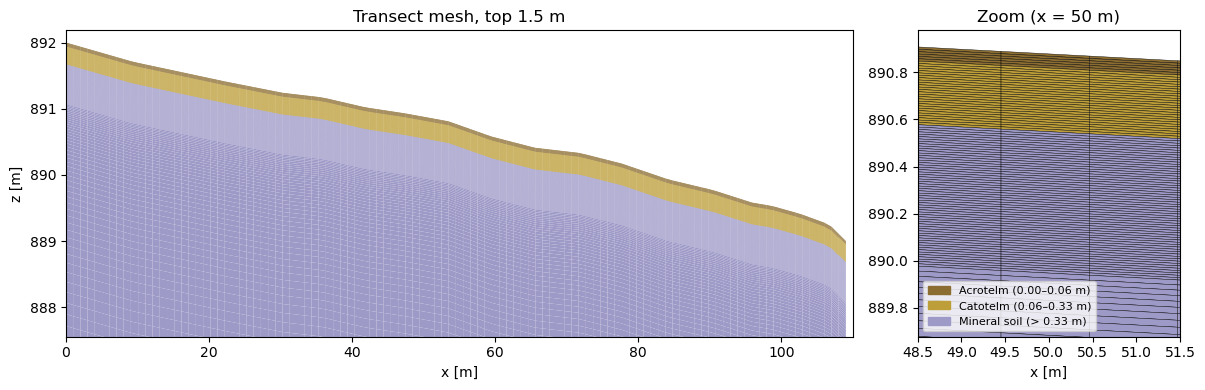

In [5]:
LAYERS = [("Acrotelm", 0.00, 0.06, "#8c6d31"),
          ("Catotelm", 0.06, 0.33, "#bd9e39"),
          ("Mineral soil", 0.33, np.inf, "#9e9ac8")]

vis = ats_xdmf.VisFile(os.path.join(RUNS, "run03_transect_base_sigma4_6yr"), time_unit="d")
vis.loadMeshPolygons()
vis_s = ats_xdmf.VisFile(os.path.join(RUNS, "run03_transect_base_sigma4_6yr"), "surface", time_unit="d")
vis_s.loadMesh(order=["x", "z"])
elev = vis_s.get("surface-elevation", vis.cycles[0])
x_surf = vis_s.centroids[:, 0]

polys = vis.getMeshPolygons(linewidth=0)
centroids = np.array([p.vertices.mean(axis=0) for p in polys.get_paths()])
depth = np.interp(centroids[:, 0], x_surf, elev) - centroids[:, 1]
layer_id = np.select([depth < 0.06, depth < 0.33], [0, 1], default=2)
polys.set_facecolor([LAYERS[i][3] for i in layer_id])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].add_collection(polys)
axes[0].set_xlim(0, 110)
axes[0].set_ylim(elev.min() - 1.5, elev.max() + 0.2)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("z [m]")
axes[0].set_title("Transect mesh, top 1.5 m")
# zoom on a 3 m x 1.2 m window to show vertical refinement
polys_zoom = vis.getMeshPolygons(linewidth=0.3, edgecolor="k")
polys_zoom.set_facecolor([LAYERS[i][3] for i in layer_id])
axes[1].add_collection(polys_zoom)
x0 = 50.0
z0 = np.interp(x0, x_surf, elev)
axes[1].set_xlim(x0 - 1.5, x0 + 1.5)
axes[1].set_ylim(z0 - 1.2, z0 + 0.1)
axes[1].set_xlabel("x [m]")
axes[1].set_title("Zoom (x = 50 m)")
axes[1].legend(handles=[mpl.patches.Patch(color=c, label=f"{n} ({a:.2f}–{b:.2f} m)" if np.isfinite(b) else f"{n} (> {a:.2f} m)")
                        for n, a, b, c in LAYERS], fontsize=8, loc="lower left")
fig.tight_layout()
savefig(fig, "Fig1_mesh.pdf")
plt.show()

## Figure 2: synthetic summer rain ensembles

(a) Daily rain over the summer window (mean freshet day to mean end of streamflow, from the Imnavait Creek weir record, 1985–2017) for all 40 years of DAAC forcing, fitted with a lognormal PDF. The fitted shape parameter defines σ5. (b) Lognormal PDFs for σ1–σ9 with the mean held fixed. (c) The twelve rain realizations per σ, as applied in the simulations. The rain is taken from the model's own `rain [m/d]` output, so it matches the forcing files exactly.

The ensemble forcing files are generated by `gen_ensemble_rain_forcings.py`.

In [6]:
def lognormal_pdf(x, mu, sigma):
    return 1.0 / (x * sigma * np.sqrt(2 * np.pi)) * np.exp(-((np.log(x) - mu) ** 2) / (2 * sigma ** 2))


# summer window from the weir record
q = pd.read_csv(os.path.join(DATA, "ImnavaitCr_Historical_Discharge_1985_2017_2018Aug6.csv"),
                usecols=["Date", "Discharge"], low_memory=False)
q["Date"] = pd.to_datetime(q["Date"], errors="coerce")
q["Discharge"] = pd.to_numeric(q["Discharge"], errors="coerce").replace(6999, np.nan)
q = q.dropna()
freshet, end = [], []
for _, yr in q.groupby(q["Date"].dt.year):
    may = yr[yr["Date"].dt.month == 5]
    if not may.empty:
        freshet.append(may.loc[may["Discharge"].idxmax(), "Date"].dayofyear)
    summer = yr[yr["Date"].dt.month.between(5, 9) & (yr["Discharge"] > 0)]
    if not summer.empty:
        end.append(summer["Date"].iloc[-1].dayofyear)
start_doy = (pd.Timestamp("2020-01-01") + pd.Timedelta(days=np.mean(freshet) - 1)).dayofyear
end_doy = (pd.Timestamp("2020-01-01") + pd.Timedelta(days=np.mean(end) - 1)).dayofyear
print(f"summer window: DOY {start_doy}–{end_doy} (leap-year calendar)")

rain = daac.loc[daac["DOY"].between(start_doy, end_doy), "Precipitation Rain [m s^-1]"] * 8.64e7
hist, edges = np.histogram(rain, bins=50, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
pos = rain[rain > 0]
(mu_fit, sig_fit), _ = curve_fit(lognormal_pdf, centers[centers > 0], hist[centers > 0],
                                 p0=[np.log(pos).mean(), np.log(pos).std()])
logn_mean = np.exp(mu_fit + sig_fit ** 2 / 2)
print(f"lognormal fit: mu = {mu_fit:.2f}, sigma = {sig_fit:.2f}  (manuscript: 0.40, 1.48)")

SIGMA_OFFSETS = [-0.9, -0.8, -0.7, -0.4, 0.0, 0.4, 0.7, 0.8, 0.9]
sigma_vals = [sig_fit + d for d in SIGMA_OFFSETS]
print("sigma_1..sigma_9 =", np.round(sigma_vals, 2))

summer window: DOY 141–252 (leap-year calendar)
lognormal fit: mu = 0.40, sigma = 1.48  (manuscript: 0.40, 1.48)
sigma_1..sigma_9 = [0.58 0.68 0.78 1.08 1.48 1.88 2.18 2.28 2.38]


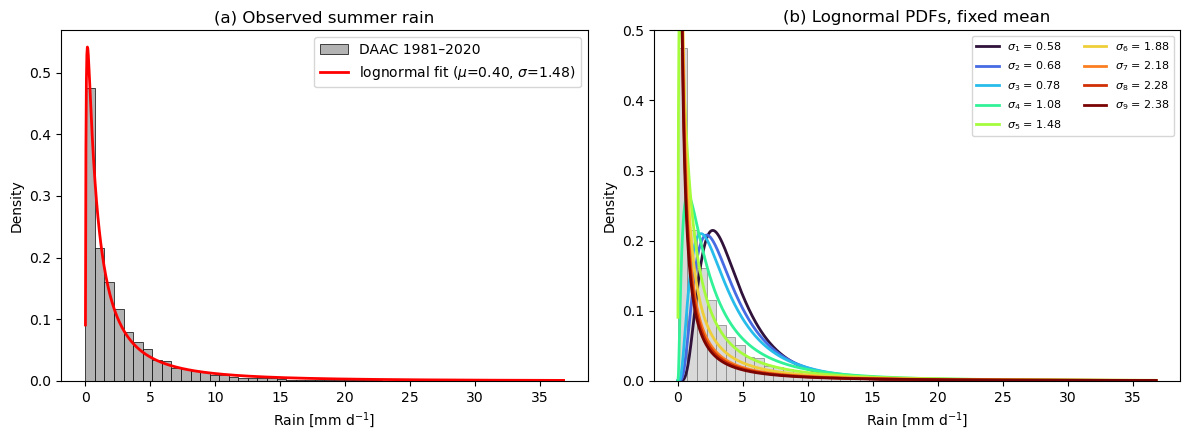

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.linspace(0.01, rain.max(), 1000)
axes[0].hist(rain, bins=edges, density=True, color="0.7", edgecolor="k", lw=0.5, label="DAAC 1981–2020")
axes[0].plot(x, lognormal_pdf(x, mu_fit, sig_fit), "r-", lw=2,
             label=rf"lognormal fit ($\mu$={mu_fit:.2f}, $\sigma$={sig_fit:.2f})")
axes[0].set(xlabel="Rain [mm d$^{-1}$]", ylabel="Density", title="(a) Observed summer rain")
axes[0].legend()

axes[1].hist(rain, bins=edges, density=True, color="0.85", edgecolor="0.5", lw=0.5)
for s, sig in zip(SIGMAS, sigma_vals):
    axes[1].plot(x, lognormal_pdf(x, np.log(logn_mean) - sig ** 2 / 2, sig), color=SIGMA_COLORS[s], lw=2,
                 label=f"{ms(s)} = {sig:.2f}")
axes[1].set(xlabel="Rain [mm d$^{-1}$]", ylabel="Density", ylim=(0, 0.5),
            title="(b) Lognormal PDFs, fixed mean")
axes[1].legend(ncol=2, fontsize=8)
fig.tight_layout()
savefig(fig, "Fig2ab_lognormal_fit_pdfs.pdf")
plt.show()

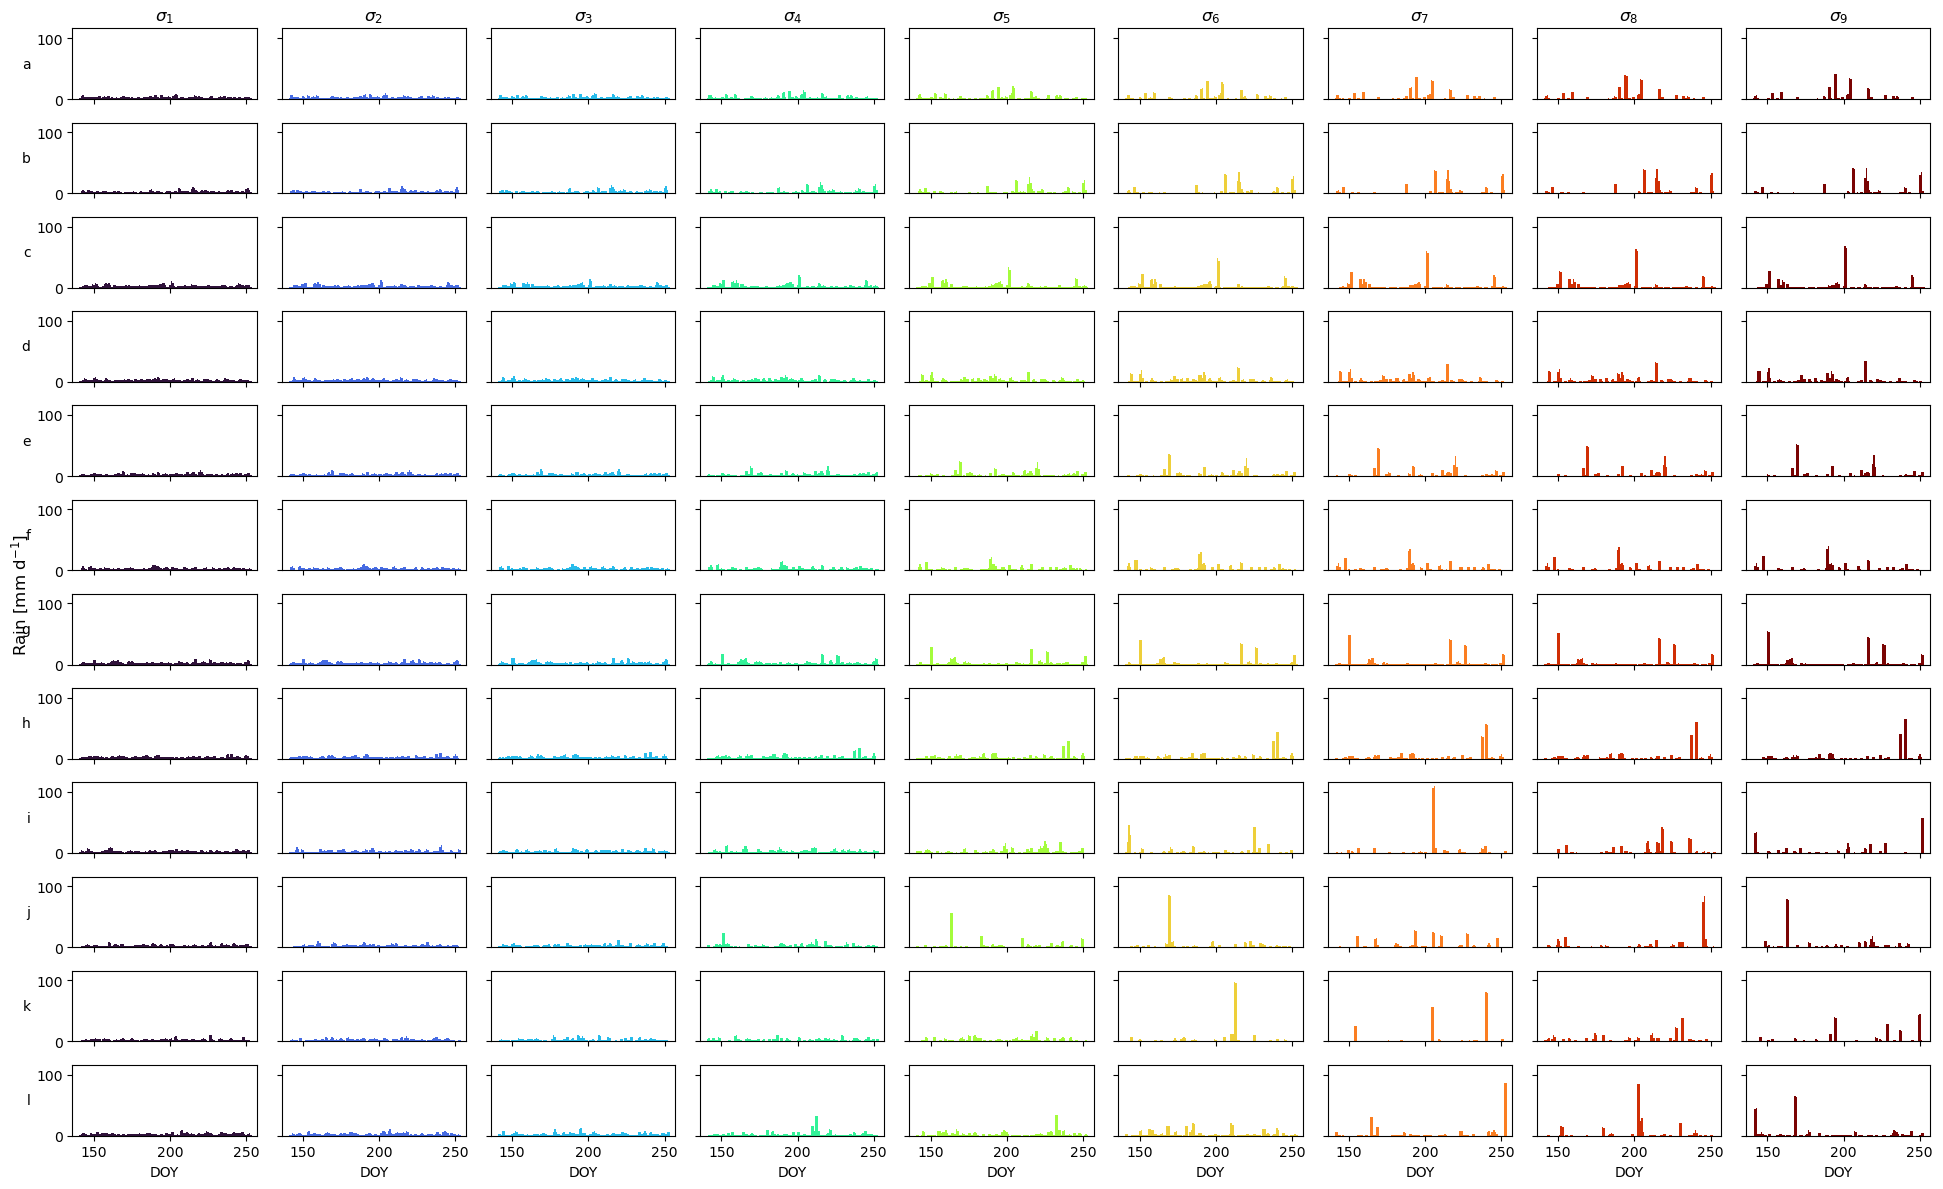

seasonal rain total [mm]: min 395.12, max 398.03


In [8]:
fig, axes = plt.subplots(len(REPS), len(SIGMAS), figsize=(2.2 * len(SIGMAS), 1.0 * len(REPS)),
                         sharex=True, sharey=True)
for j, s in enumerate(SIGMAS):
    for i, rep in enumerate(REPS):
        r = ens[s][rep]["rain [m/d]"] * 1000
        axes[i, j].bar(r.index, r, width=1, color=SIGMA_COLORS[s], lw=0)
        axes[i, j].set_xlim(start_doy - 5, end_doy + 5)
        if i == 0:
            axes[i, j].set_title(ms(s))
        if j == 0:
            axes[i, j].set_ylabel(rep, rotation=0, ha="right", va="center")
for ax in axes[-1]:
    ax.set_xlabel("DOY")
fig.supylabel("Rain [mm d$^{-1}$]")
fig.tight_layout()
savefig(fig, "Fig2c_rain_ensembles.pdf")
plt.show()

# total summer rain is identical across all 108 realizations
tot = pd.Series({(s, r): ens[s][r]["rain [m/d]"].sum() * 1000 for s in SIGMAS for r in REPS})
print(f"seasonal rain total [mm]: min {tot.min():.2f}, max {tot.max():.2f}")

## Figures 3 and 4: groundwater flow and saturation around a July storm

σ1, σ5 and σ9 (runs `sigma0`, `sigma4`, `sigma8`), BASE run year 4. Output frames 1293 (before the storm) and 1295 (during the storm) of the original output are stored in the trimmed `ats_vis_*.h5` files of each `run03` directory (see `trim_vis_output.py`). The published Figures 3 and 4 were assembled from these panels:

* **Figure 3**: rain hyetograph and log-scaled outflow (time series), flux magnitude and direction, and liquid saturation before the storm
* **Figure 4**: flux magnitude and direction before (top) and during (bottom) the storm

Elevations are shown with 10.7× vertical exaggeration and a shear that removes the ~2 % hillslope gradient.

In [9]:
VIS_FRAMES = {"before": 0, "during": 2}   # indices into the trimmed files = original frames 1293, 1295
FIG34_SIGMAS = [0, 4, 8]
YEAR_START = datetime(1981, 1, 1)          # day 0 of the simulation calendar
VE, SHEAR_MULT = 10.7, 0.6


def flux_cmap():
    """Pastel nipy_spectral, top 5 % blended to maroon (as published)."""
    c = plt.get_cmap("nipy_spectral", 256)(np.linspace(0, 1, 256))
    white = np.ones(4)
    c = 0.8 * c + 0.2 * white
    n_rep = int(0.05 * 256)
    start, maroon = c[256 - n_rep - 10].copy(), 0.8 * np.array([0.4, 0, 0, 1]) + 0.2 * white
    for i in range(256 - n_rep, 256):
        frac = (i - (256 - n_rep)) / n_rep
        c[i] = (1 - frac) * start + frac * maroon
    cm = mpl.colors.ListedColormap(c)
    cm.set_bad("white")
    return cm


class Transect:
    """Trimmed vis output of one run, with the sheared/exaggerated plotting geometry."""

    def __init__(self, s):
        d = os.path.join(RUNS, f"run03_transect_base_sigma{s}_6yr")
        self.vis = ats_xdmf.VisFile(d, time_unit="d")
        self.vis.loadMeshPolygons()
        vs = ats_xdmf.VisFile(d, "surface", time_unit="d")
        vs.loadMesh(order=["x", "z"])
        self.x_surf = vs.centroids[:, 0]
        self.elev = vs.get("surface-elevation", self.vis.cycles[0])
        paths = self.vis.getMeshPolygons().get_paths()
        self.centroids = np.array([p.vertices.mean(axis=0) for p in paths])
        self.depth = np.interp(self.centroids[:, 0], self.x_surf, self.elev) - self.centroids[:, 1]
        self.shear = -np.polyfit(self.x_surf, self.elev, 1)[0] * (VE - 1) * SHEAR_MULT
        self.verts = []
        for p in paths:
            v = p.vertices.copy()
            v[:, 1] = VE * v[:, 1] + self.shear * v[:, 0]
            self.verts.append(v)

    def date(self, k):
        return YEAR_START + timedelta(days=int(self.vis.times[k]))

    def frame(self, ax, values, cmap, clim, depth_limit):
        keep = self.depth <= depth_limit          # draw only the near-surface cells
        pc = PolyCollection([v for v, k in zip(self.verts, keep) if k], cmap=cmap, linewidth=0)
        pc.set_array(np.asarray(values)[keep])
        pc.set_clim(*clim)
        pc.set_alpha(0.9)
        ax.add_collection(pc)
        ax.set_xlim(0, 110)
        ax.set_ylim(VE * 888.9 + 13, VE * 892.1 + self.shear * 110 - 16)
        ax.set_ylabel(f"Elevation (V.E. = {VE:.1f}×) [m]")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)
        return pc

    def flux(self, ax, k, depth_limit=0.55):
        vx = self.vis.get("darcy_velocity.0", self.vis.cycles[k])
        vz = self.vis.get("darcy_velocity.2", self.vis.cycles[k])
        vlog = np.log10(np.hypot(vx, vz) * 100 * 86400 + 1e-10)          # log10 [cm/d]
        pc = self.frame(ax, vlog, flux_cmap(), (0.5, 2.0), depth_limit)
        # unit arrows on a subsampled grid (every 3rd column, 7th row)
        xu = np.unique(np.round(self.centroids[:, 0], 2))
        zu = np.unique(np.round(self.centroids[:, 1], 2))
        xi = np.abs(self.centroids[:, [0]] - xu[None, :]).argmin(axis=1)
        zi = np.abs(self.centroids[:, [1]] - zu[None, :]).argmin(axis=1)
        m = (xi % 3 == 0) & (zi % 7 == 0) & (vlog >= -0.6) & (self.depth <= depth_limit)
        mag = np.hypot(vx[m], vz[m])
        ux, uz = vx[m] / mag, vz[m] / mag
        tx, tz = ux + self.shear * uz, VE * uz
        tm = np.hypot(tx, tz)
        c = self.centroids[m]
        ax.quiver(c[:, 0], VE * c[:, 1] + self.shear * c[:, 0], tx / tm, tz / tm, angles="xy", scale=30,
                  width=0.0007, headwidth=14, headlength=16, headaxislength=16,
                  facecolors="white", edgecolors="black", linewidth=0.6, zorder=5)
        return pc

    def saturation(self, ax, k, depth_limit=0.50):
        cm = plt.get_cmap("jet_r").copy()
        cm.set_bad("white")
        return self.frame(ax, self.vis.get("saturation_liquid", self.vis.cycles[k]), cm, (0.7, 1.0), depth_limit)


def colorbar(fig, ax, pc, label):
    cax = make_axes_locatable(ax).append_axes("right", size="2%", pad=0.07)
    fig.colorbar(pc, cax=cax).set_label(label)


transects = {s: Transect(s) for s in FIG34_SIGMAS}
for s, t in transects.items():
    print(ms(s), {k: t.date(i).strftime("%d %B") for k, i in VIS_FRAMES.items()},
          "days", t.vis.times)

$\sigma_{1}$ {'before': '18 July', 'during': '20 July'} days [1294. 1295. 1296.]
$\sigma_{5}$ {'before': '18 July', 'during': '20 July'} days [1294. 1295. 1296.]
$\sigma_{9}$ {'before': '18 July', 'during': '20 July'} days [1294. 1295. 1296.]


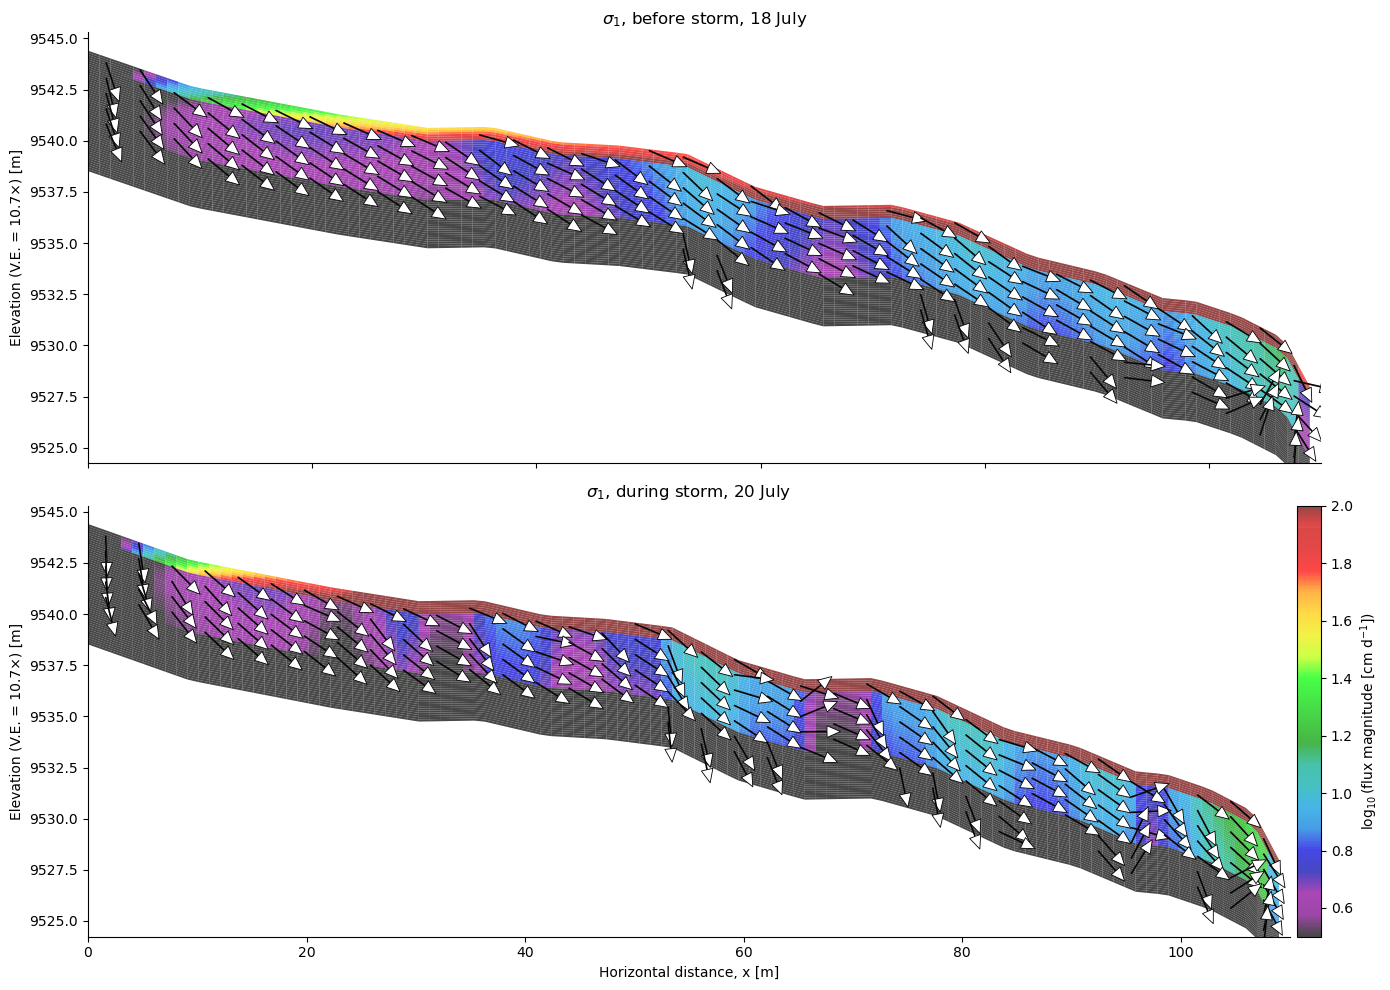

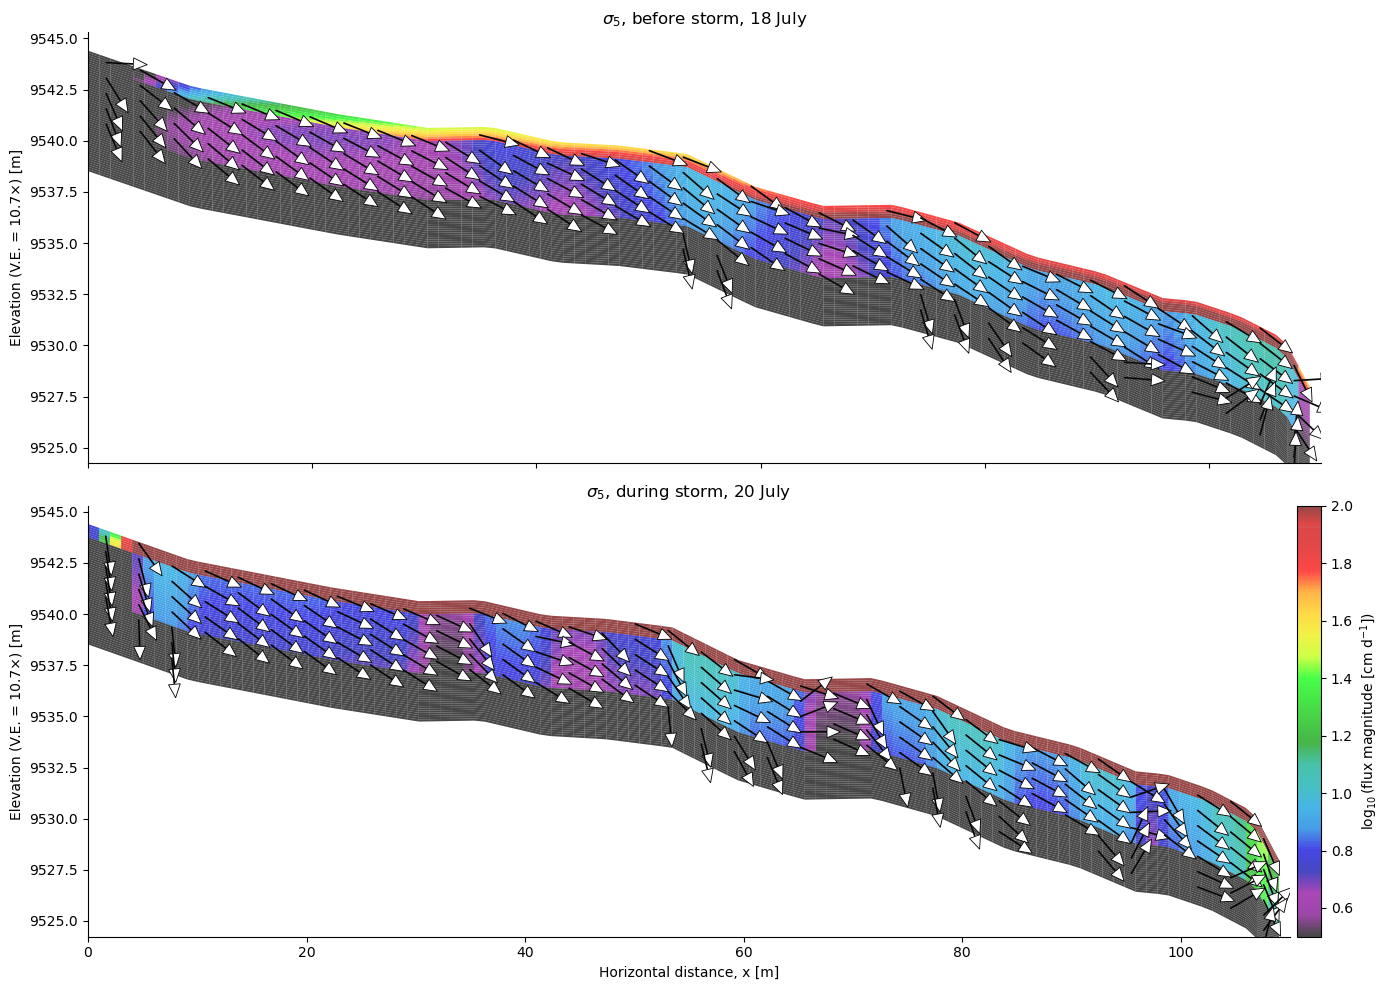

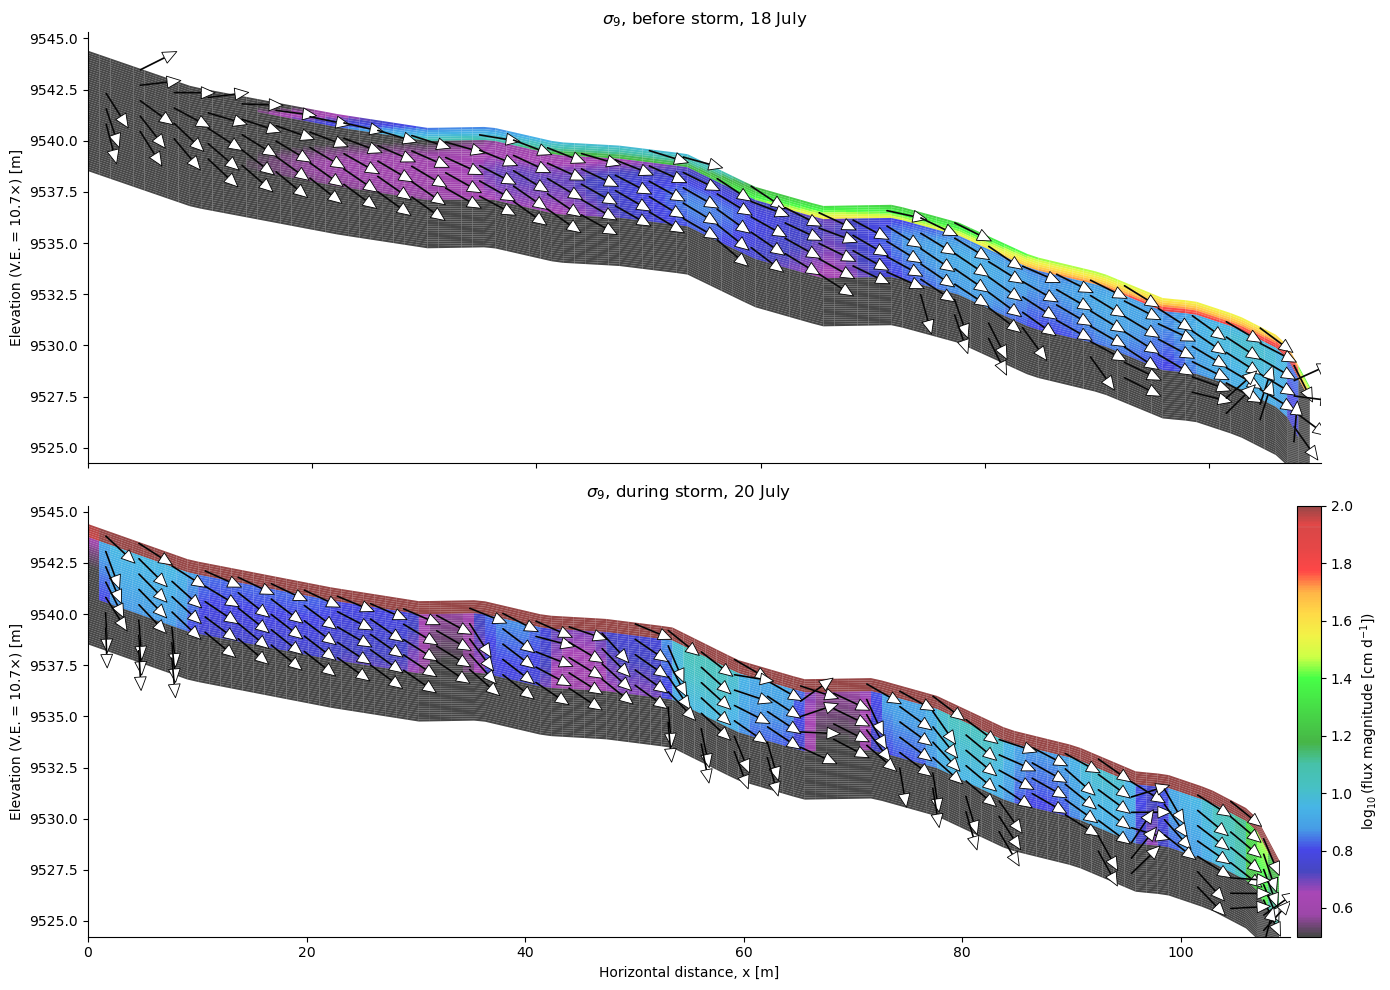

In [10]:
# Figure 3/4 flux panels: before (top) and during (bottom) the storm
for s, t in transects.items():
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    for ax, (when, k) in zip(axes, VIS_FRAMES.items()):
        pc = t.flux(ax, k)
        ax.set_title(f"{ms(s)}, {when} storm, {t.date(k):%d %B}")
    axes[-1].set_xlabel("Horizontal distance, x [m]")
    colorbar(fig, axes[-1], pc, r"$\log_{10}$(flux magnitude [cm d$^{-1}$])")
    fig.tight_layout()
    savefig(fig, f"Fig3-4_flux_sigma{s + 1}.pdf")
    plt.show()

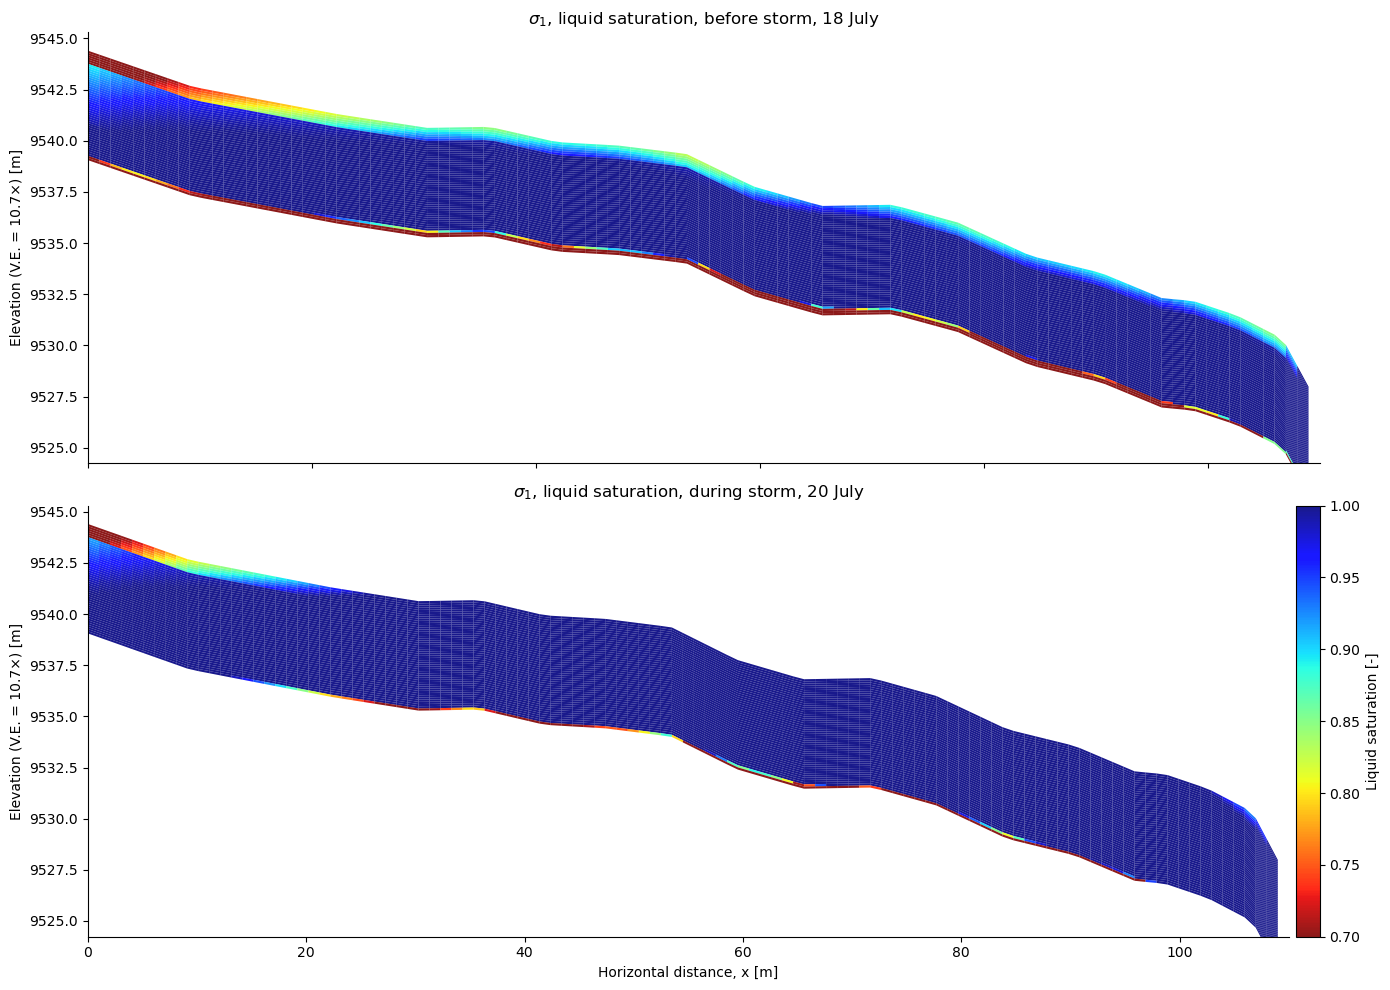

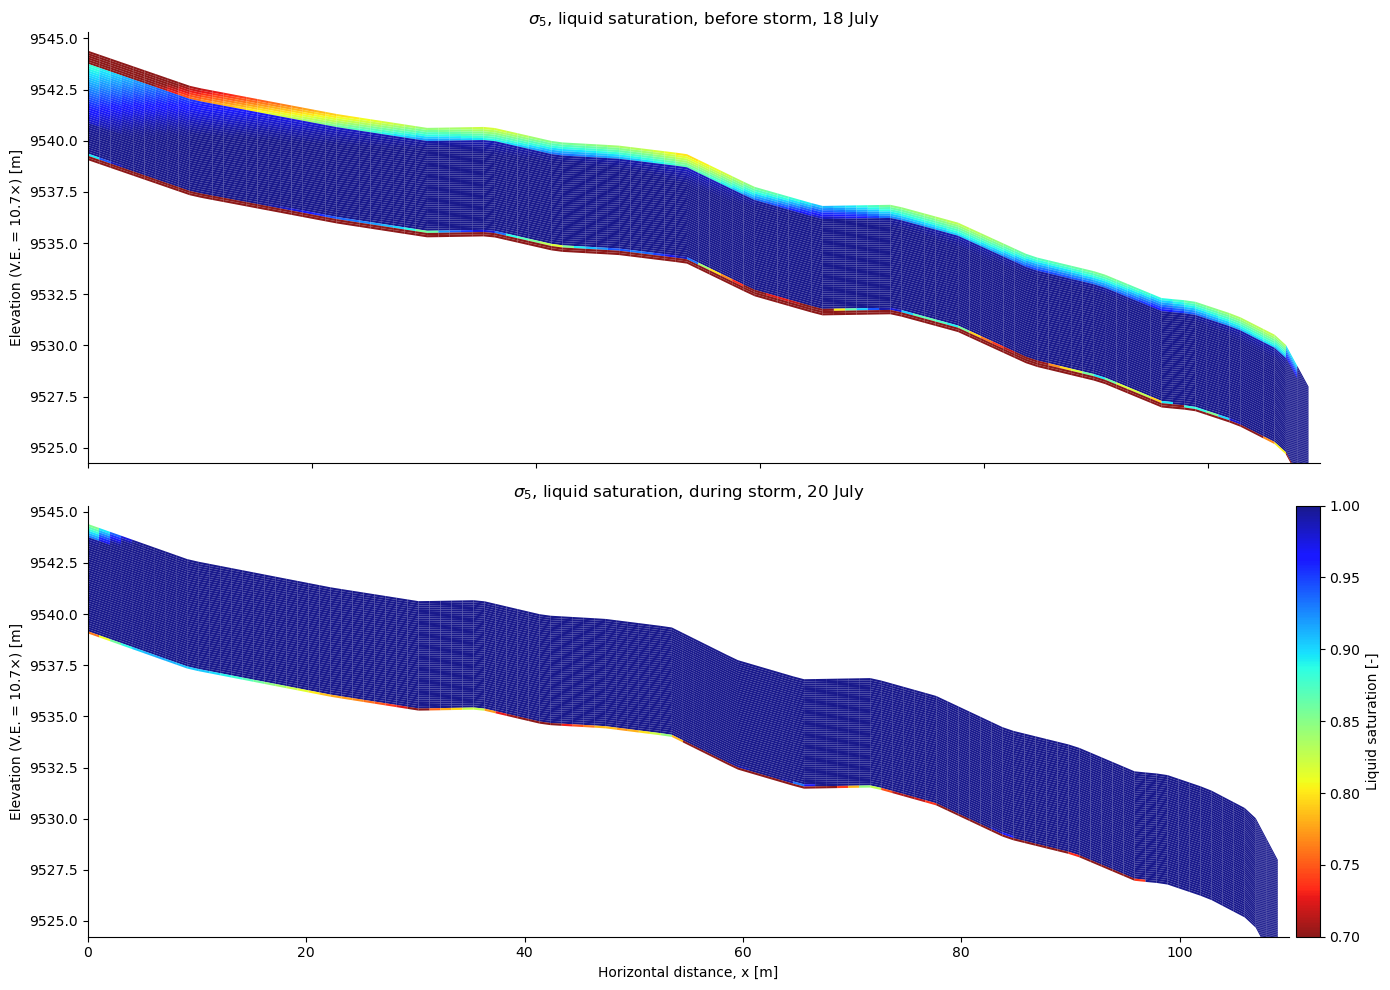

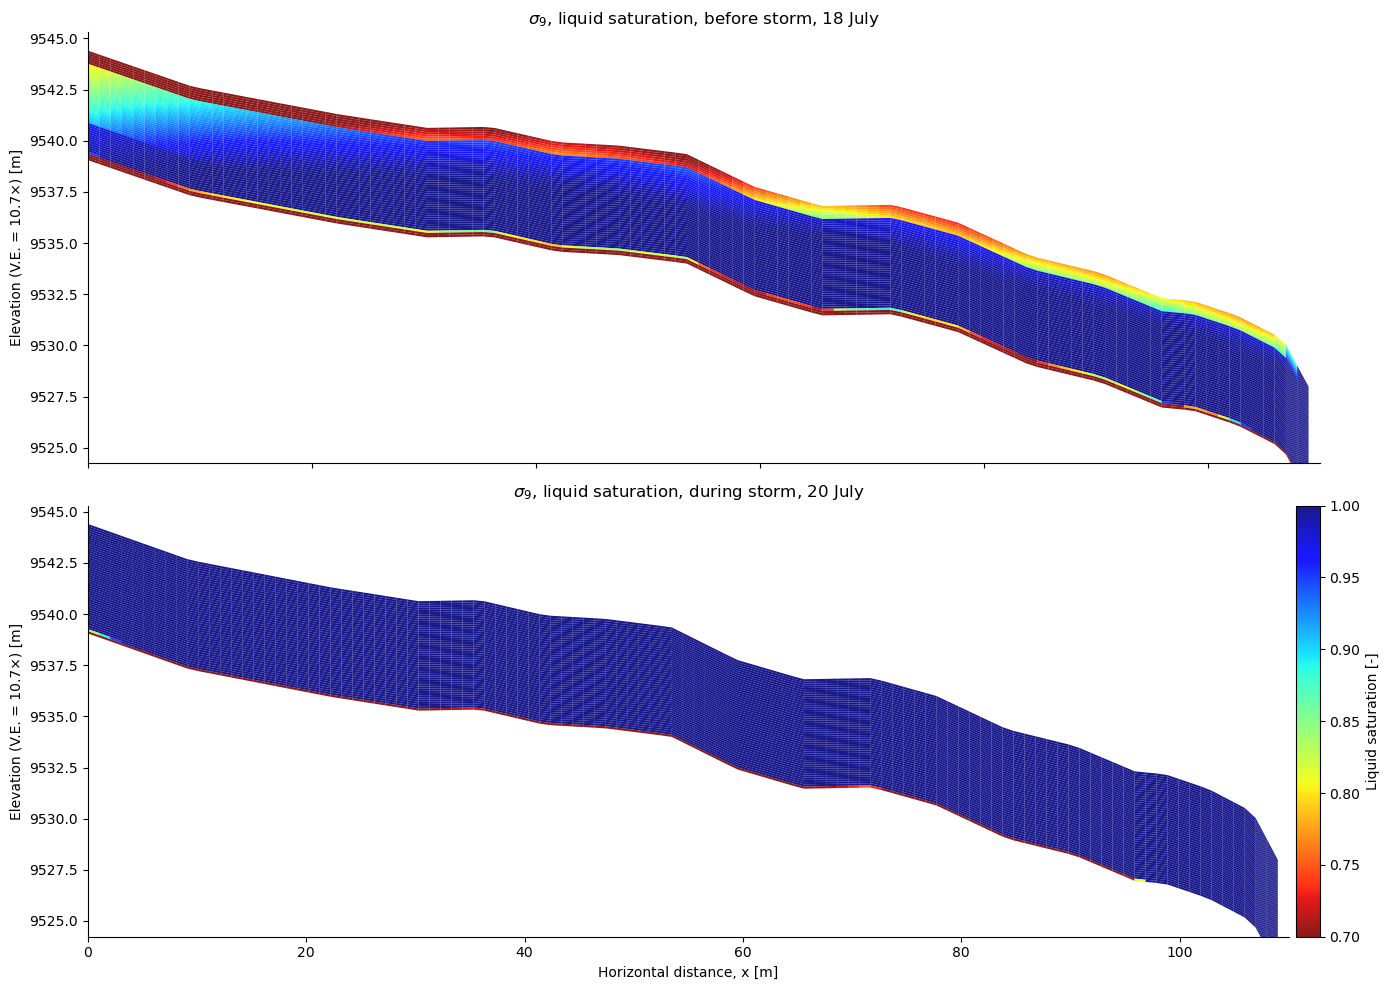

In [11]:
# Figure 3 saturation panels
for s, t in transects.items():
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    for ax, (when, k) in zip(axes, VIS_FRAMES.items()):
        pc = t.saturation(ax, k)
        ax.set_title(f"{ms(s)}, liquid saturation, {when} storm, {t.date(k):%d %B}")
    axes[-1].set_xlabel("Horizontal distance, x [m]")
    colorbar(fig, axes[-1], pc, "Liquid saturation [-]")
    fig.tight_layout()
    savefig(fig, f"Fig3_saturation_sigma{s + 1}.pdf")
    plt.show()

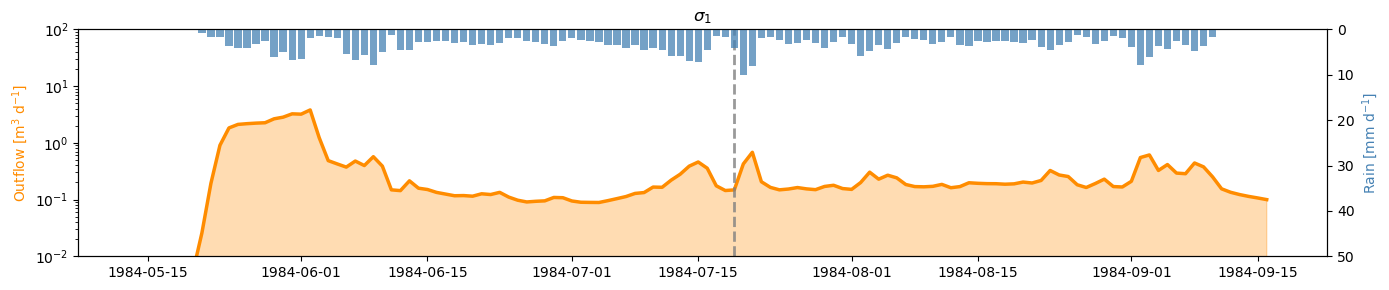

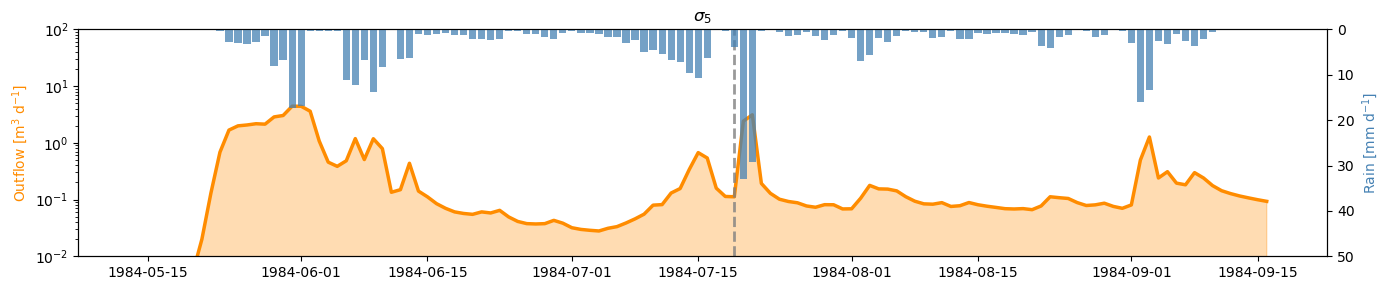

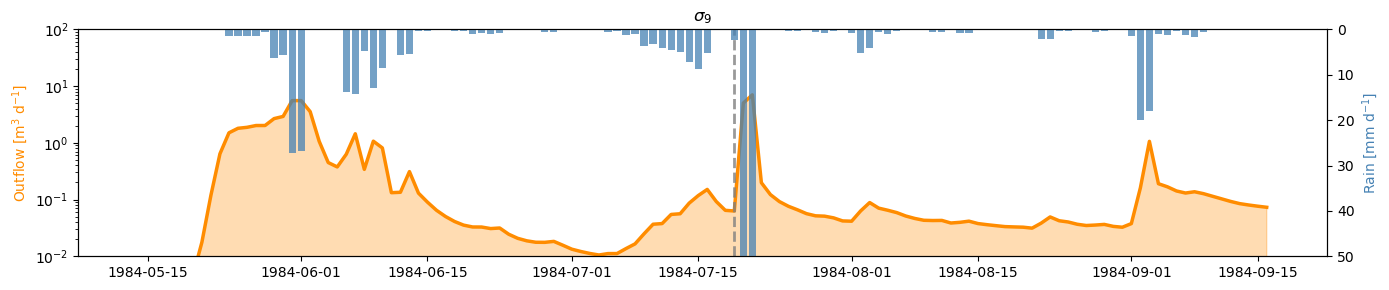

In [12]:
# Figure 3 hyetograph and hydrograph (DOY 135-260 of the storm year)
for s, t in transects.items():
    df = read_obs(f"run03_transect_base_sigma{s}_6yr")
    df["date"] = YEAR_START + pd.to_timedelta(df["time [d]"], unit="d")
    storm = t.date(1)
    y0 = pd.Timestamp(year=storm.year, month=1, day=1)
    sub = df[df["date"].between(y0 + pd.Timedelta(days=134), y0 + pd.Timedelta(days=259))]
    runoff = sub["net runoff [mol/d]"] / MOL_PER_M3

    fig, ax1 = plt.subplots(figsize=(14, 3))
    ax1.plot(sub["date"], runoff, color="darkorange", lw=2.5)
    ax1.fill_between(sub["date"], 1e-6, runoff, color="darkorange", alpha=0.3)
    ax1.axvline(storm, color="gray", ls="--", lw=2, alpha=0.8)
    ax1.set_yscale("log")
    ax1.set_ylim(1e-2, 1e2)
    ax1.set_ylabel("Outflow [m$^3$ d$^{-1}$]", color="darkorange")
    ax2 = ax1.twinx()
    ax2.bar(sub["date"], sub["rain [m/d]"] * 1000, width=0.8, color="steelblue", alpha=0.75)
    ax2.set_ylim(50, 0)
    ax2.set_ylabel("Rain [mm d$^{-1}$]", color="steelblue")
    ax1.set_title(ms(s))
    fig.tight_layout()
    savefig(fig, f"Fig3_hydrograph_sigma{s + 1}.pdf")
    plt.show()

## Figure 5: cumulative outflow, water and ice tables, saturated thickness

All 108 realizations (9 σ × 12), day-of-year 150–260. Saturated thickness = ice-table (thaw) depth − water-table depth, floored at 0.

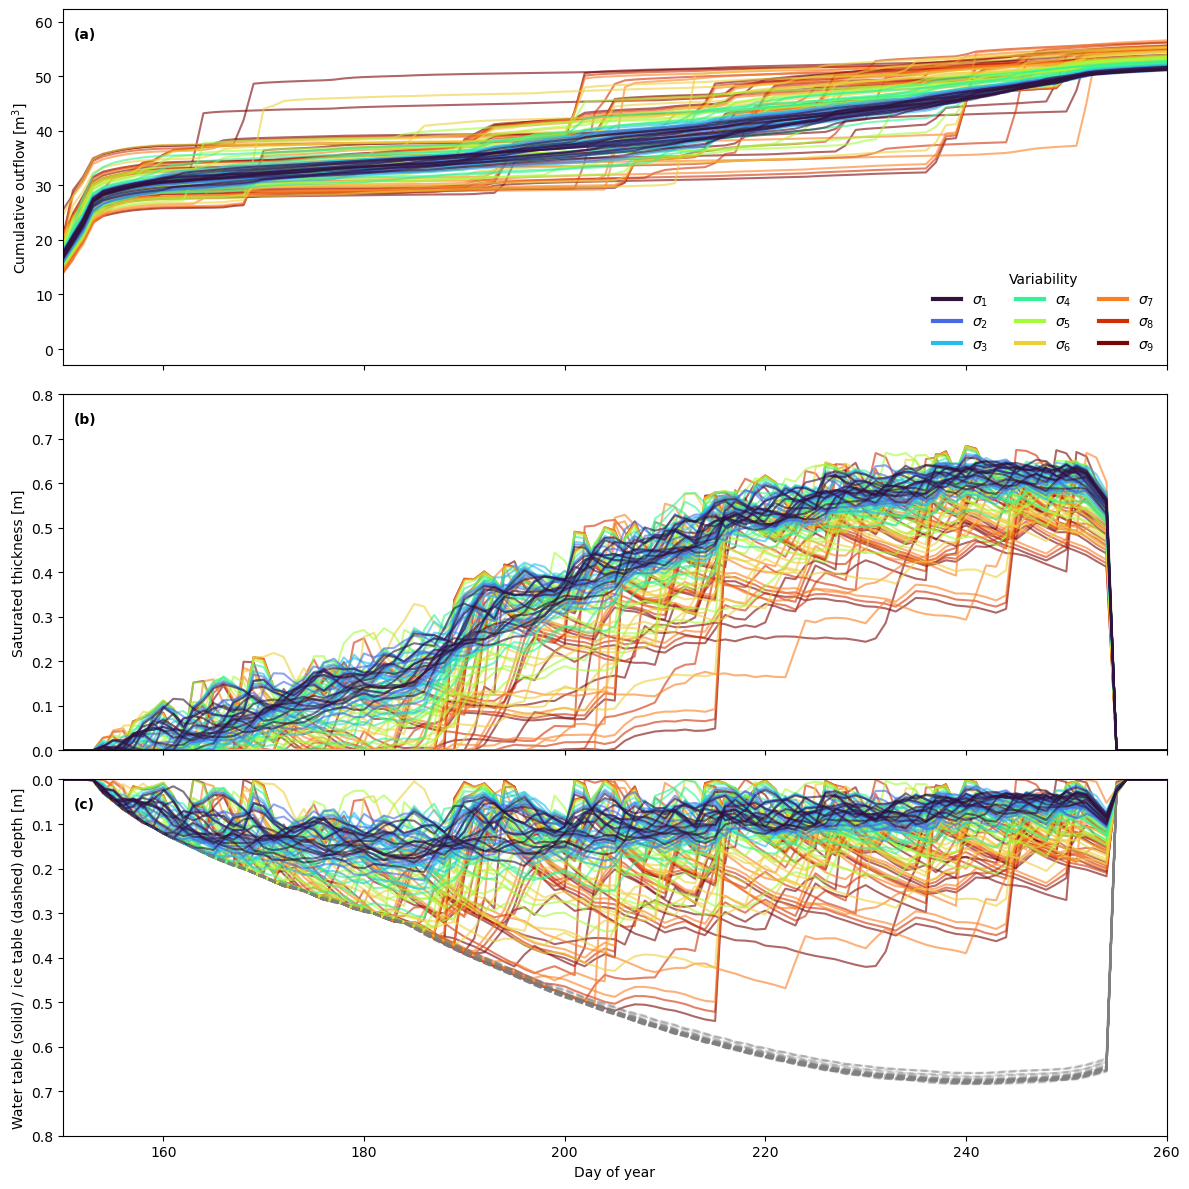

In [13]:
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for s in reversed(SIGMAS):
    for rep in REPS:
        df = ens[s][rep]
        td, wtd = df["thaw depth [m]"], df["water table depth [m]"]
        ax0.plot(df.index, df["net runoff [mol/d]"].cumsum() / MOL_PER_M3, color=SIGMA_COLORS[s], alpha=0.6)
        ax1.plot(df.index, np.maximum(td - wtd, 0), color=SIGMA_COLORS[s], alpha=0.6)
        ax2.plot(df.index, td, "--", color="gray", alpha=0.1)
        ax2.plot(df.index, np.minimum(wtd, td), color=SIGMA_COLORS[s], alpha=0.6)
ax0.set_ylabel("Cumulative outflow [m$^3$]")
ax0.legend(handles=[Line2D([0], [0], color=SIGMA_COLORS[s], lw=3, label=ms(s)) for s in SIGMAS],
           title="Variability", loc="lower right", ncol=3, frameon=False)
ax1.set(ylabel="Saturated thickness [m]", ylim=(0, 0.8))
ax2.set(xlabel="Day of year", ylabel="Water table (solid) / ice table (dashed) depth [m]",
        xlim=SEASON, ylim=(0.8, 0))
for ax, lab in zip((ax0, ax1, ax2), "abc"):
    ax.text(0.01, 0.95, f"({lab})", transform=ax.transAxes, va="top", fontweight="bold")
fig.tight_layout()
savefig(fig, "Fig5_outflow_watertable_saturated_thickness.pdf")
plt.show()

## Figure 6: wet and dry days per soil layer

For each day of the 150–260 window, a layer is **dry** if the water table lies below its thawed bottom, **wet** if the water table lies above its top, and **mixed** if the water table lies within it. Blue bars show wet + mixed days and brown bars show dry days, one bar per realization.

The settings below reproduce the published figure, which used realizations a–h and a catotelm bottom of 0.20 m. Note that Section 2.2 of the manuscript places the catotelm at 6–33 cm.

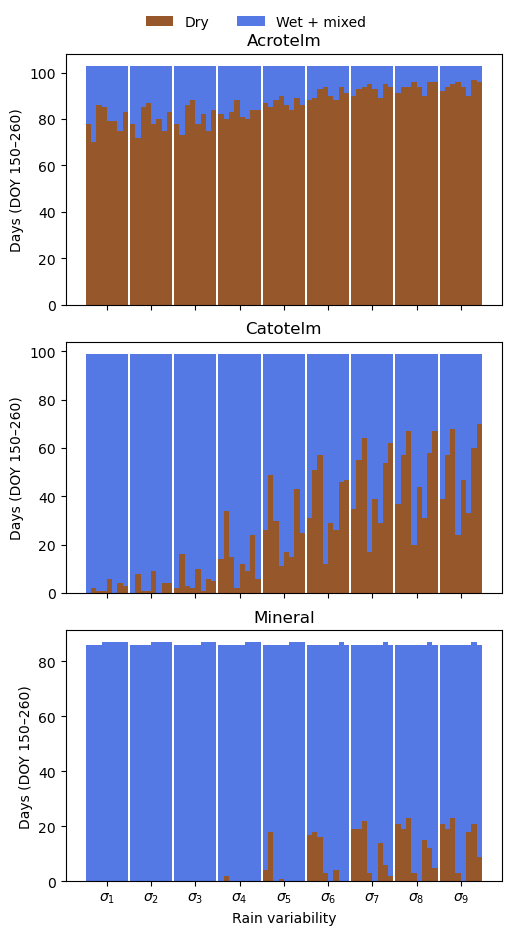

min                      mean                       max           \
band  Acrotelm Catotelm Mineral Acrotelm Catotelm Mineral Acrotelm Catotelm   
sigma                                                                         
0           70        0       0     79.4      2.1     0.0       86        6   
1           72        0       0     79.8      3.4     0.0       87        9   
2           73        1       0     80.5      5.6     0.0       88       16   
3           80        2       0     82.8     14.5     0.2       88       34   
4           84       11       0     86.9     27.0     2.9       90       49   
5           88       12       0     90.9     37.4     7.2       94       57   
6           89       17       0     92.9     44.4    10.6       95       64   
7           90       20       0     93.9     47.6    12.2       96       67   
8           90       24       0     94.2     49.8    14.2       97       70   

               
band  Mineral  
sigma          
0           0  
1           0  
2           0  
3           2  
4          18  
5          18  
6          22  
7          23  
8          23

In [14]:
FIG6_REPS = SHARED_SEED_REPS                 # published: a-h  (all 12: REPS)
FIG6_BANDS = [("Acrotelm", 0.00, 0.06),
              ("Catotelm", 0.06, 0.20),      # published: 0.20 m  (mesh: 0.33 m)
              ("Mineral", 0.20, None)]       # None = down to the thaw depth


def layer_status(wtd, itd, top, bot):
    bottom = itd if bot is None else min(bot, itd)
    if bottom <= top:
        return "frozen"
    if wtd <= top:
        return "wet"
    if wtd >= bottom:
        return "dry"
    return "mixed"


rows = []
for s in SIGMAS:
    for rep in FIG6_REPS:
        sub = ens[s][rep].loc[SEASON[0]:SEASON[1]]
        for name, top, bot in FIG6_BANDS:
            st = pd.Series([layer_status(w, i, top, bot)
                            for w, i in zip(sub["water table depth [m]"], sub["thaw depth [m]"])])
            rows.append(dict(sigma=s, rep=rep, band=name, dry=(st == "dry").sum(),
                             wet_mixed=st.isin(["wet", "mixed"]).sum()))
wetdry = pd.DataFrame(rows)

width = 0.13
group = width * len(FIG6_REPS) + 0.05
xb = np.arange(len(SIGMAS)) * group
fig, axes = plt.subplots(len(FIG6_BANDS), 1, figsize=(5, 9), sharex=True, constrained_layout=True)
for ax, (name, _, _) in zip(axes, FIG6_BANDS):
    d = wetdry[wetdry["band"] == name]
    for i, rep in enumerate(FIG6_REPS):
        r = d[d["rep"] == rep].set_index("sigma").reindex(SIGMAS)
        xr = xb + i * width - (len(FIG6_REPS) - 1) * width / 2
        ax.bar(xr, r["dry"], width, color="saddlebrown", alpha=0.9, label="Dry" if i == 0 else None)
        ax.bar(xr, r["wet_mixed"], width, bottom=r["dry"], color="royalblue", alpha=0.9,
               label="Wet + mixed" if i == 0 else None)
    ax.set_title(name)
    ax.set_ylabel(f"Days (DOY {SEASON[0]}–{SEASON[1]})")
axes[-1].set_xticks(xb, [ms(s) for s in SIGMAS])
axes[-1].set_xlabel("Rain variability")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.03))
savefig(fig, "Fig6_wet_dry_days_by_layer.pdf")
plt.show()

wetdry.groupby(["band", "sigma"])["dry"].agg(["min", "mean", "max"]).unstack("band").round(1)

## Figure 7: integrated fluxes and flashiness

Per realization (365-day year): Richards–Baker flashiness index of daily outflow, and cumulative outflow, evapotranspiration and surface-to-subsurface exchange. Circles mark shared-seed realizations (a–h) and diamonds mark unique-seed realizations (i–l). Panel (e) pools all 108 realizations; Kendall's τ and the Theil–Sen slope are descriptive.

In [15]:
def rb_flashiness(q):
    q = np.asarray(q)
    return np.nan if q.sum() == 0 else np.abs(np.diff(q)).sum() / q.sum()


fluxes = pd.DataFrame([
    dict(sigma=s, rep=rep, seed="shared" if rep in SHARED_SEED_REPS else "unique",
         flashiness=rb_flashiness(df["net runoff [mol/d]"]),
         outflow_m3=df["net runoff [mol/d]"].sum() / MOL_PER_M3,
         et_m3=df["evaporation cumulation [m3/d]"].sum(),
         # ATS sign convention: surface -> subsurface flux is negative; reported as positive infiltration
         exchange_m3=-df["surface-subsurface exchange cumulation [mol/d]"].sum() / MOL_PER_M3)
    for s in SIGMAS for rep, df in ens[s].items()])

summary7 = fluxes.groupby("sigma")[["outflow_m3", "et_m3", "exchange_m3", "flashiness"]].agg(["mean", "min", "max"])
summary7.index = [f"sigma_{s + 1}" for s in summary7.index]
summary7.round(2)

outflow_m3                et_m3               exchange_m3         \
              mean    min    max   mean    min    max        mean    min   
sigma_1      54.28  54.02  54.70  11.52  11.00  11.84       13.59  13.15   
sigma_2      54.29  53.94  54.88  11.53  10.81  11.96       13.60  12.97   
sigma_3      54.48  54.11  55.09  11.33  10.60  11.80       13.40  12.77   
sigma_4      54.99  54.38  55.71  10.87   9.92  11.58       12.92  12.12   
sigma_5      55.72  54.78  56.58  10.15   9.01  11.22       12.21  11.26   
sigma_6      56.61  55.21  57.88   9.28   8.06  10.78       11.35  10.06   
sigma_7      57.24  55.65  59.34   8.60   6.67  10.41       10.73   8.68   
sigma_8      57.29  55.71  58.94   8.60   6.79  10.28       10.70   8.96   
sigma_9      57.38  55.63  58.33   8.48   7.51  10.15       10.61   9.68   

               flashiness              
           max       mean   min   max  
sigma_1  13.88       0.25  0.23  0.27  
sigma_2  13.99       0.27  0.25  0.29  
sigma_3  13.80       0.29  0.27  0.32  
sigma_4  13.56       0.34  0.31  0.40  
sigma_5  13.18       0.42  0.37  0.50  
sigma_6  12.74       0.50  0.43  0.58  
sigma_7  12.34       0.56  0.47  0.62  
sigma_8  12.21       0.54  0.48  0.63  
sigma_9  12.10       0.56  0.49  0.64

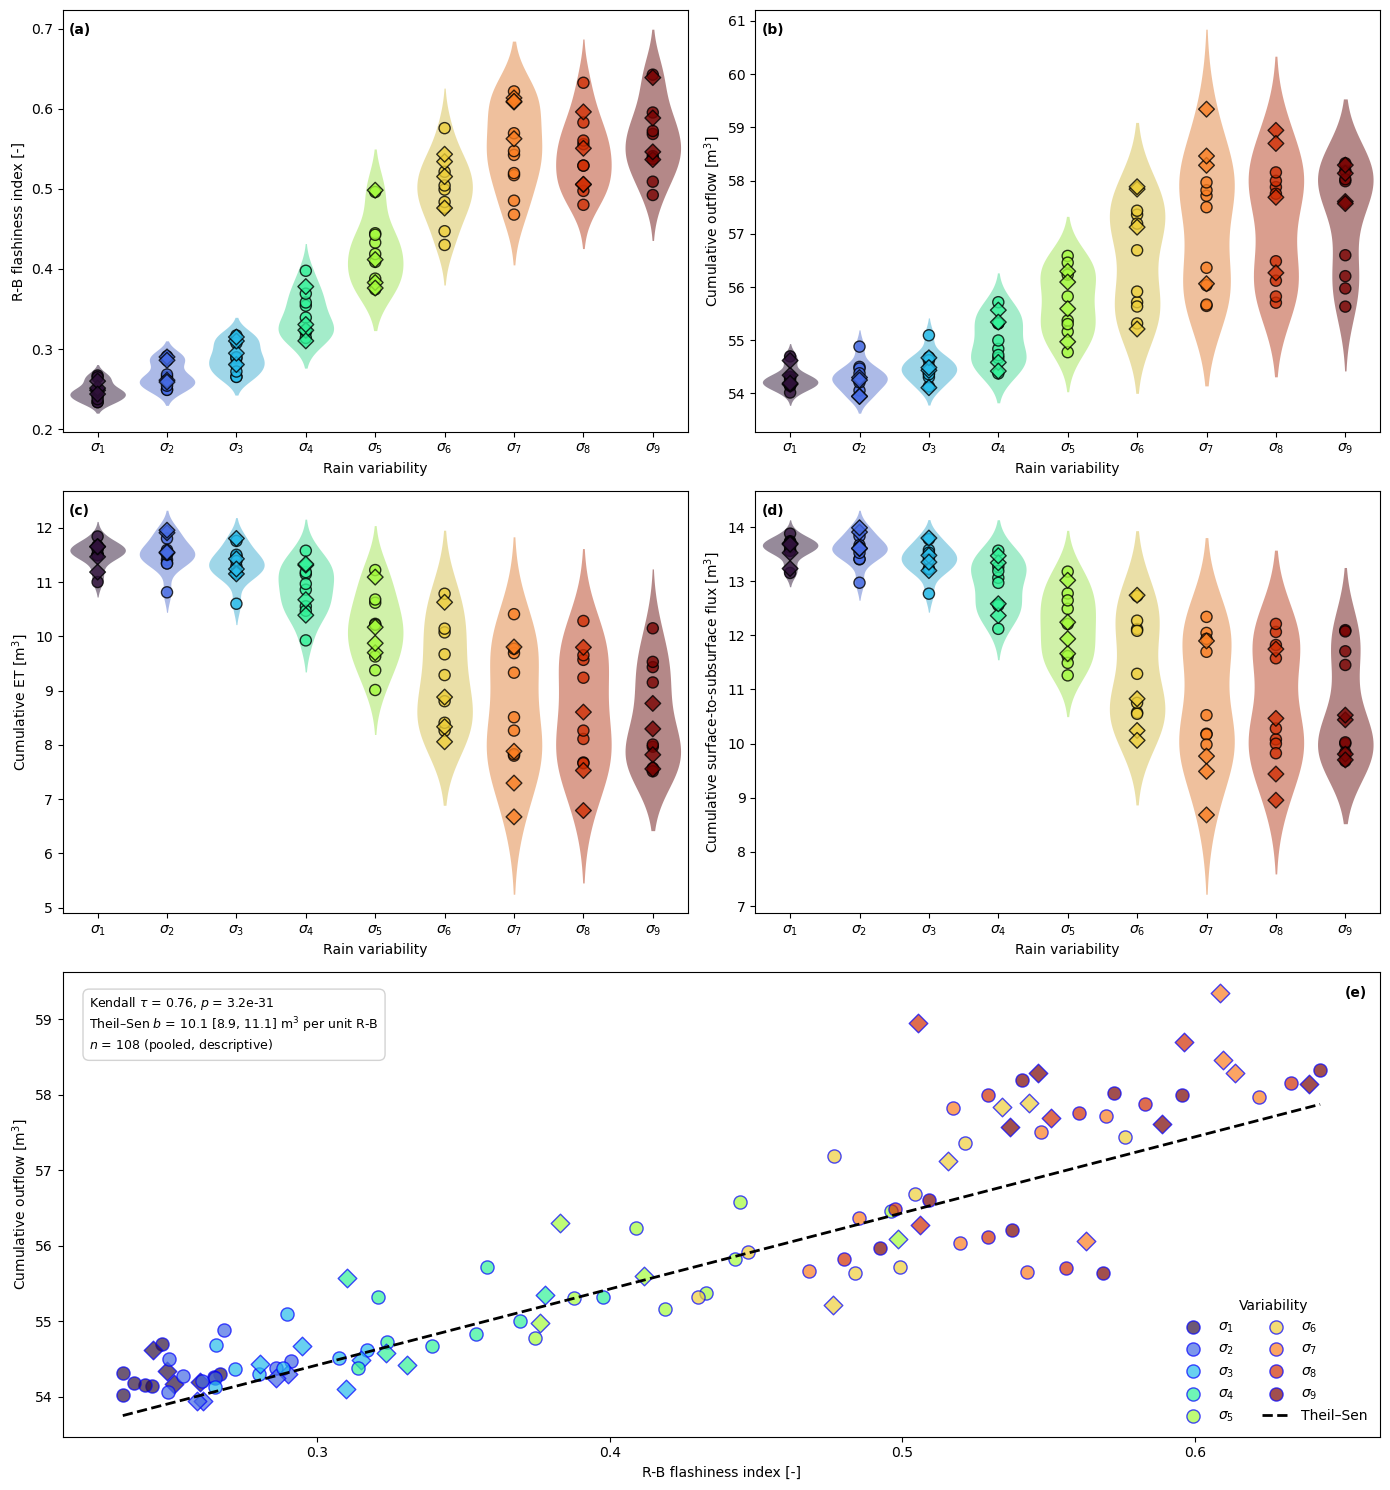

Fig 7e: Kendall tau = 0.76, p = 3.15e-31  (manuscript: 0.8, 3.2e-31)


In [16]:
PANELS7 = [("flashiness", "R-B flashiness index [-]"),
           ("outflow_m3", "Cumulative outflow [m$^3$]"),
           ("et_m3", "Cumulative ET [m$^3$]"),
           ("exchange_m3", "Cumulative surface-to-subsurface flux [m$^3$]")]
palette = {s: SIGMA_COLORS[s] for s in SIGMAS}

fig = plt.figure(figsize=(14, 15))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1])
for k, (col, label) in enumerate(PANELS7):
    ax = fig.add_subplot(gs[k // 2, k % 2])
    sns.violinplot(data=fluxes, x="sigma", y=col, hue="sigma", palette=palette, inner=None,
                   linewidth=0, alpha=0.5, legend=False, ax=ax)
    for seed, marker in [("shared", "o"), ("unique", "D")]:
        sns.stripplot(data=fluxes[fluxes["seed"] == seed], x="sigma", y=col, hue="sigma", palette=palette,
                      jitter=False, marker=marker, size=8, edgecolor="k", linewidth=1, alpha=0.8,
                      legend=False, ax=ax)
    ax.set_xticks(range(len(SIGMAS)), [ms(s) for s in SIGMAS])
    ax.set(xlabel="Rain variability", ylabel=label)
    ax.text(0.01, 0.97, f"({'abcd'[k]})", transform=ax.transAxes, va="top", fontweight="bold")

ax = fig.add_subplot(gs[2, :])
x, y = fluxes["flashiness"].values, fluxes["outflow_m3"].values
slope, icept, lo, hi = theilslopes(y, x)
tau, p = kendalltau(x, y)
for s in SIGMAS:
    for seed, marker in [("shared", "o"), ("unique", "D")]:
        d = fluxes[(fluxes["sigma"] == s) & (fluxes["seed"] == seed)]
        ax.scatter(d["flashiness"], d["outflow_m3"], color=SIGMA_COLORS[s], marker=marker, s=90,
                   edgecolor="b", alpha=0.7, label=ms(s) if seed == "shared" else None)
xs = np.sort(x)
ax.plot(xs, icept + slope * xs, "k--", lw=2, label="Theil–Sen")
ax.text(0.02, 0.95, rf"Kendall $\tau$ = {tau:.2f}, $p$ = {p:.1e}" "\n"
        rf"Theil–Sen $b$ = {slope:.1f} [{lo:.1f}, {hi:.1f}] m$^3$ per unit R-B" "\n"
        rf"$n$ = {len(x)} (pooled, descriptive)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="lightgrey"))
ax.set(xlabel="R-B flashiness index [-]", ylabel="Cumulative outflow [m$^3$]")
ax.legend(title="Variability", frameon=False, loc="lower right", ncol=2)
ax.text(0.99, 0.97, "(e)", transform=ax.transAxes, va="top", ha="right", fontweight="bold")
fig.tight_layout()
savefig(fig, "Fig7_fluxes_flashiness.pdf")
plt.show()
print(f"Fig 7e: Kendall tau = {tau:.2f}, p = {p:.2e}  (manuscript: 0.8, 3.2e-31)")

## Figure 8: outflow ranking and flashiness within each σ group

(a) Cumulative outflow for the 12 realizations of each σ, coloured from lowest (blue) to highest (red) seasonal total within that group. (b) Seasonal cumulative outflow vs. R-B flashiness within each group: Kendall's τ (exact p, n = 12), Benjamini–Hochberg q across the nine groups, and Theil–Sen slope b with 95 % CI.

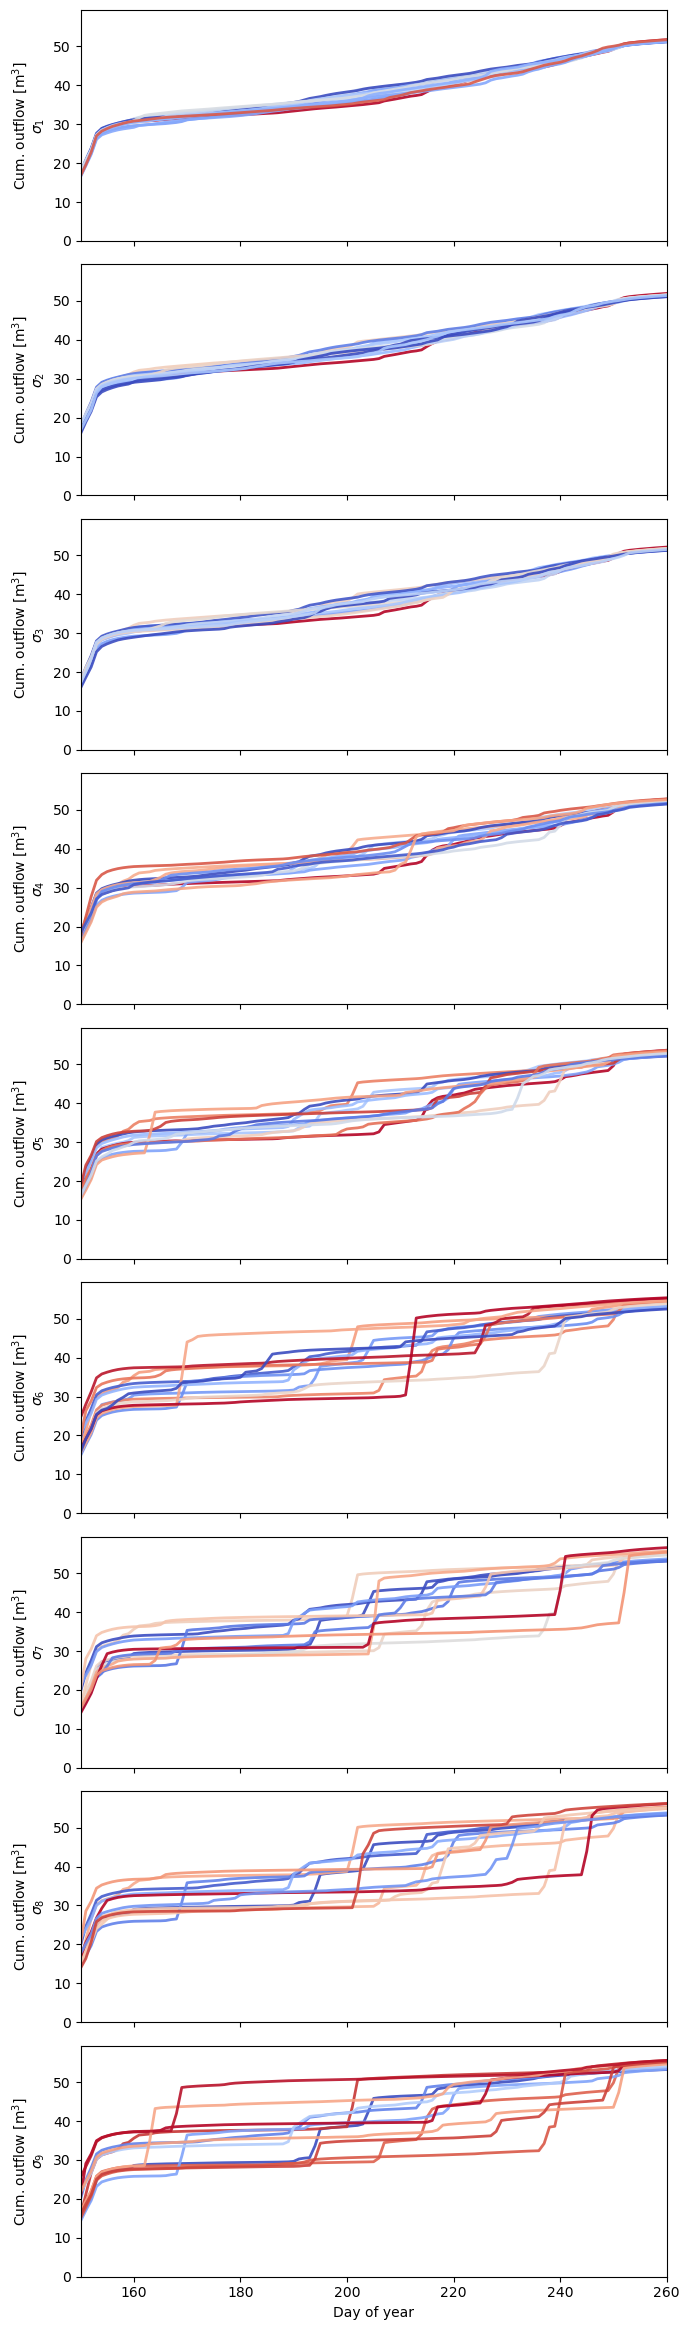

In [17]:
cum_max = max((df["net runoff [mol/d]"].cumsum() / MOL_PER_M3).max() for s in SIGMAS for df in ens[s].values())
fig, axes = plt.subplots(len(SIGMAS), 1, figsize=(7, 2.6 * len(SIGMAS)), sharex=True)
for ax, s in zip(axes, SIGMAS):
    finals = {rep: df["net runoff [mol/d]"].sum() / MOL_PER_M3 for rep, df in ens[s].items()}
    norm = mcolors.Normalize(min(finals.values()), max(finals.values()))
    for rep, df in ens[s].items():
        ax.plot(df.index, df["net runoff [mol/d]"].cumsum() / MOL_PER_M3,
                color=plt.cm.coolwarm(norm(finals[rep])), lw=2, alpha=0.9)
    ax.set(xlim=SEASON, ylim=(0, cum_max), ylabel=f"Cum. outflow [m$^3$]\n{ms(s)}")
axes[-1].set_xlabel("Day of year")
fig.tight_layout()
savefig(fig, "Fig8a_cumulative_outflow_ranked.pdf")
plt.show()

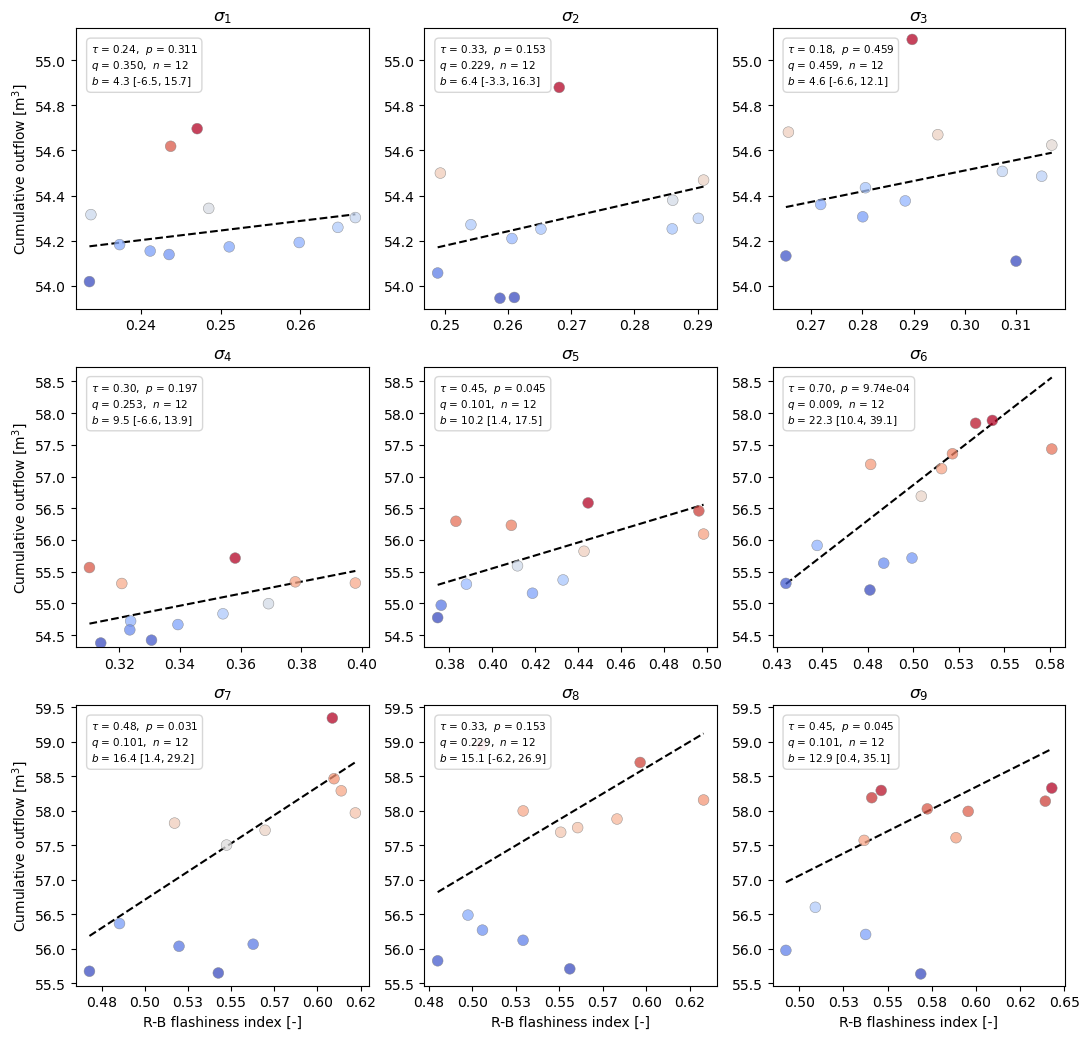

,n,tau,p,q,slope,lo,hi
sigma_1,12.0,0.2424,0.3108,0.3497,4.2640,-6.4925,15.7252
sigma_2,12.0,0.3333,0.1526,0.2289,6.4198,-3.2844,16.3016
sigma_3,12.0,0.1818,0.4590,0.4590,4.6487,-6.6035,12.1118
sigma_4,12.0,0.3030,0.1969,0.2532,9.4773,-6.5815,13.8841
sigma_5,12.0,0.4545,0.0447,0.1007,10.1996,1.4423,17.4885
sigma_6,12.0,0.6970,0.0010,0.0088,22.3033,10.3709,39.1199
sigma_7,12.0,0.4848,0.0311,0.1007,16.3644,1.4102,29.2472
sigma_8,12.0,0.3333,0.1526,0.2289,15.0807,-6.2146,26.8716
sigma_9,12.0,0.4545,0.0447,0.1007,12.8559,0.3569,35.1344


In [18]:
stats8 = {}
for s, d in fluxes.groupby("sigma"):
    t, pv = kendalltau(d["flashiness"], d["outflow_m3"])
    b, a, blo, bhi = theilslopes(d["outflow_m3"], d["flashiness"])
    stats8[s] = dict(n=len(d), tau=t, p=pv, slope=b, icept=a, lo=blo, hi=bhi)
for s, qv in zip(SIGMAS, false_discovery_control([stats8[s]["p"] for s in SIGMAS])):
    stats8[s]["q"] = qv

fmt = lambda v: f"{v:.2e}" if v < 0.001 else f"{v:.3f}"
fig, axes = plt.subplots(3, 3, figsize=(11, 10.5))
for ax, s in zip(axes.flat, SIGMAS):
    d, st = fluxes[fluxes["sigma"] == s], stats8[s]
    xs = np.sort(d["flashiness"].values)
    ax.plot(xs, st["icept"] + st["slope"] * xs, "k--", lw=1.5)
    ax.scatter(d["flashiness"], d["outflow_m3"], c=d["outflow_m3"], cmap="coolwarm", s=60,
               edgecolors="grey", linewidths=0.4, alpha=0.75, zorder=3)
    ax.text(0.05, 0.95, rf"$\tau$ = {st['tau']:.2f},  $p$ = {fmt(st['p'])}" "\n"
            rf"$q$ = {fmt(st['q'])},  $n$ = {st['n']}" "\n"
            rf"$b$ = {st['slope']:.1f} [{st['lo']:.1f}, {st['hi']:.1f}]",
            transform=ax.transAxes, va="top", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="lightgrey", alpha=0.9))
    ax.set_title(ms(s))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
for row in axes:
    lo_, hi_ = min(a.get_ylim()[0] for a in row), max(a.get_ylim()[1] for a in row)
    for a in row:
        a.set_ylim(lo_, hi_)
for a in axes[:, 0]:
    a.set_ylabel("Cumulative outflow [m$^3$]")
for a in axes[-1]:
    a.set_xlabel("R-B flashiness index [-]")
fig.tight_layout()
savefig(fig, "Fig8b_flashiness_vs_outflow_by_sigma.pdf")
plt.show()

pd.DataFrame(stats8).T.rename(index=lambda s: f"sigma_{s + 1}")[["n", "tau", "p", "q", "slope", "lo", "hi"]].round(4)